In [1]:
import kagglehub

path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/new-plant-diseases-dataset


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.applications import VGG19
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [3]:
train_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CLASS_COUNT = 38
EPOCHS = 10

In [4]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [5]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

valid_generator = valid_datagen.flow_from_directory(
    valid_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 70295 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.


In [6]:
def VGG_transfer_model(input_shape=(224, 224, 3), classes=38):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the base

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model

model = VGG_transfer_model(input_shape=(224, 224, 3), classes=CLASS_COUNT)

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Define the checkpoint callback
checkpoint_callback = ModelCheckpoint(
    '/content/drive/MyDrive/models/checkpoint_model.h5',
    save_best_only=True,
    monitor='val_loss',
    verbose=1,
    save_weights_only=False
)

In [9]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint_callback]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 660ms/step - accuracy: 0.1113 - loss: 5.5332
Epoch 1: val_loss improved from inf to 1.82870, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1627s 733ms/step - accuracy: 0.1113 - loss: 5.5325 - val_accuracy: 0.6309 - val_loss: 1.8287
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.3592 - loss: 2.2883
Epoch 2: val_loss improved from 1.82870 to 0.94812, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1197s 545ms/step - accuracy: 0.3592 - loss: 2.2882 - val_accuracy: 0.7861 - val_loss: 0.9481
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 503ms/step - accuracy: 0.4966 - loss: 1.7055
Epoch 3: val_loss improved from 0.94812 to 0.70412, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1221s 556ms/step - accuracy: 0.4966 - loss: 1.7055 - val_accuracy: 0.8206 - val_loss: 0.7041
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step - accuracy: 0.5674 - loss: 1.4366
Epoch 4: val_loss improved from 0.70412 to 0.58284, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


...

2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1235s 562ms/step - accuracy: 0.6429 - loss: 1.1596 - val_accuracy: 0.8652 - val_loss: 0.4778
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 494ms/step - accuracy: 0.6643 - loss: 1.0850
Epoch 7: val_loss improved from 0.47778 to 0.43536, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1229s 559ms/step - accuracy: 0.6643 - loss: 1.0850 - val_accuracy: 0.8790 - val_loss: 0.4354
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.6800 - loss: 1.0353
Epoch 8: val_loss improved from 0.43536 to 0.42320, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1207s 549ms/step - accuracy: 0.6800 - loss: 1.0353 - val_accuracy: 0.8769 - val_loss: 0.4232
Epoch 9/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.6940 - loss: 0.9903
Epoch 9: val_loss improved from 0.42320 to 0.40834, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1195s 544ms/step - accuracy: 0.6940 - loss: 0.9903 - val_accuracy: 0.8836 - val_loss: 0.4083
Epoch 10/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 495ms/step - accuracy: 0.7031 - loss: 0.9489
Epoch 10: val_loss improved from 0.40834 to 0.38123, saving model to /content/drive/MyDrive/models/checkpoint_model.h5


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 1229s 559ms/step - accuracy: 0.7031 - loss: 0.9489 - val_accuracy: 0.8873 - val_loss: 0.3812


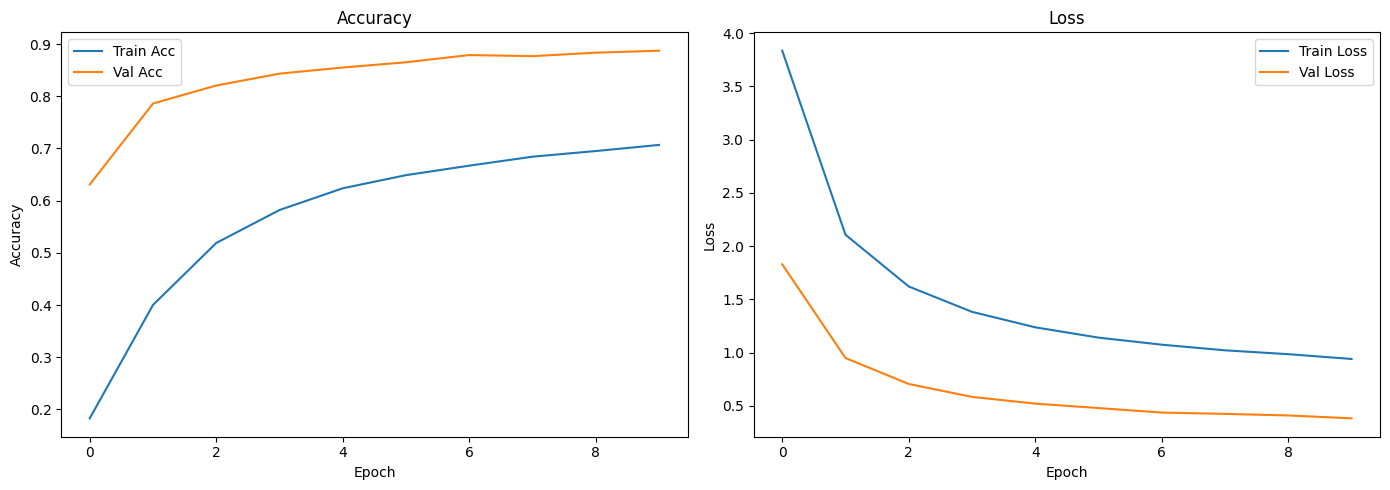

In [10]:
# ========== 8. Plot Accuracy and Loss ==========
plt.figure(figsize=(14, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()
